In [1]:
pip install gmsh numpy matplotlib

  Obtaining dependency information for gmsh from https://files.pythonhosted.org/packages/78/e9/63c763c0d75544680800651d5ea8c7c3203ae4b5e054706f19a54021a7fb/gmsh-4.15.2-py2.py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.2 MB 187.9 kB/s eta 0:03:45
   ---------------------------------------- 0.0/42.2 MB 196.9 kB/s eta 0:03:35
   ---------------------------------------- 0.1/42.2 MB 350.1 kB/s eta 0:02:01
   ---------------------------------------- 0.1/42.2 MB 425.1 kB/s eta 0:01:40
   ---------------------------------------- 0.2/42.2 MB 468.3 kB/s eta 0:01:30
   ---------------------------------------- 0.2/42.2 MB 686.6 kB/s eta 0:01:02
   ---------------------------------------


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


At first, we need to define our domain and the triangular mesh. 

In [5]:
import gmsh
import numpy as np

def generate_evacuation_mesh(lc=0.5):
    gmsh.initialize()
    gmsh.model.add("EvacuationDomain")

    # Parametri del dominio
    L = 20.0       
    W = 10.0       
    wall_x = 15.0  
    door_w = 2.0  
    eps = 1e-7 
    
    y_bottom = (W - door_w) / 2
    y_top = (W + door_w) / 2

    # --- PUNTI ---
    # Stanza Sinistra e perimetro esterno
    p1 = gmsh.model.geo.addPoint(0, 0, 0, lc)
    p2 = gmsh.model.geo.addPoint(wall_x, 0, 0, lc)      # Muro basso (lato SX)
    p3 = gmsh.model.geo.addPoint(wall_x, y_bottom, 0, lc) # Base porta (condiviso)
    p4 = gmsh.model.geo.addPoint(wall_x, y_top, 0, lc)    # Cima porta (condiviso)
    p5 = gmsh.model.geo.addPoint(wall_x, W, 0, lc)       # Muro alto (lato SX)
    p6 = gmsh.model.geo.addPoint(0, W, 0, lc)
    
# Sostituiamo wall_x con wall_x + eps per i punti della stanza destra
    p2_bis = gmsh.model.geo.addPoint(wall_x + eps, 0, 0, lc)    
    p5_bis = gmsh.model.geo.addPoint(wall_x + eps, W, 0, lc)
    # Outflow
    p7 = gmsh.model.geo.addPoint(L, 0, 0, lc)
    p8 = gmsh.model.geo.addPoint(L, W, 0, lc)
    
    # --- LINEE ---
    # Stanza Sinistra
    l_bottom1 = gmsh.model.geo.addLine(p1, p2)
    l_wall_low_L = gmsh.model.geo.addLine(p2, p3)
    l_door = gmsh.model.geo.addLine(p3, p4)             # L'UNICA connessione tra le stanze
    l_wall_hi_L = gmsh.model.geo.addLine(p4, p5)
    l_top1 = gmsh.model.geo.addLine(p5, p6)
    l_left = gmsh.model.geo.addLine(p6, p1)
    
    # Stanza Destra
    l_bottom2 = gmsh.model.geo.addLine(p2_bis, p7)
    l_outflow = gmsh.model.geo.addLine(p7, p8)
    l_top2 = gmsh.model.geo.addLine(p8, p5_bis)
    l_wall_low_R = gmsh.model.geo.addLine(p2_bis, p3)
    l_wall_hi_R = gmsh.model.geo.addLine(p4, p5_bis)

    # --- SUPERFICI ---
    # Ciclo stanza sinistra
    loop_left = gmsh.model.geo.addCurveLoop([l_bottom1, l_wall_low_L, l_door, l_wall_hi_L, l_top1, l_left])
    surf_left = gmsh.model.geo.addPlaneSurface([loop_left])
    
    # Ciclo stanza destra (notare l'uso dei segmenti _R e l'inversione della porta)
    loop_right = gmsh.model.geo.addCurveLoop([l_bottom2, l_outflow, l_top2, -l_wall_hi_R, -l_door, -l_wall_low_R])
    surf_right = gmsh.model.geo.addPlaneSurface([loop_right])

    gmsh.model.geo.synchronize()

    # --- GRUPPI FISICI ---
    gmsh.model.addPhysicalGroup(1, [l_outflow], name="Gamma_outflow")
    # Includiamo tutte le linee dei muri (sia L che R) nel gruppo "Gamma_wall"
    gmsh.model.addPhysicalGroup(1, [l_bottom1, l_bottom2, l_top1, l_top2, l_left, 
                                    l_wall_low_L, l_wall_hi_L, l_wall_low_R, l_wall_hi_R], name="Gamma_wall")
    gmsh.model.addPhysicalGroup(2, [surf_left, surf_right], name="Omega")

    gmsh.model.mesh.generate(2)
    
    # Estrazione dati
    nodeTags, nodeCoords, _ = gmsh.model.mesh.getNodes()
    nodes = np.array(nodeCoords).reshape(-1, 3)[:, :2]
    tag_to_idx = {tag: i for i, tag in enumerate(nodeTags)}
    
    elemTypes, elemTags, elemNodeTags = gmsh.model.mesh.getElements(dim=2)
    triangles = np.array([tag_to_idx[tag] for tag in elemNodeTags[0]]).reshape(-1, 3)
    
    outflow_entities = gmsh.model.getEntitiesForPhysicalGroup(1, gmsh.model.getPhysicalGroups(dim=1)[0][1])
    outflow_nodes = []
    for ent in outflow_entities:
        ntags, _, _ = gmsh.model.mesh.getNodes(1, ent)
        outflow_nodes.extend([tag_to_idx[tag] for tag in ntags])

    return nodes, triangles, list(set(outflow_nodes))

# Esecuzione
nodes, triangles, outflow = generate_evacuation_mesh(lc=0.3)

Define the algorithm for the solution of the Eikonal equation

C:\Users\Utente1\AppData\Local\Temp\ipykernel_13016\1457796382.py:32: RuntimeWarning: invalid value encountered in scalar add
  c3 = T1**2 * invA11 + 2*T1*T2*invA12 + T2**2 * invA22 - f**2
C:\Users\Utente1\AppData\Local\Temp\ipykernel_13016\1457796382.py:32: RuntimeWarning: invalid value encountered in scalar multiply
  c3 = T1**2 * invA11 + 2*T1*T2*invA12 + T2**2 * invA22 - f**2


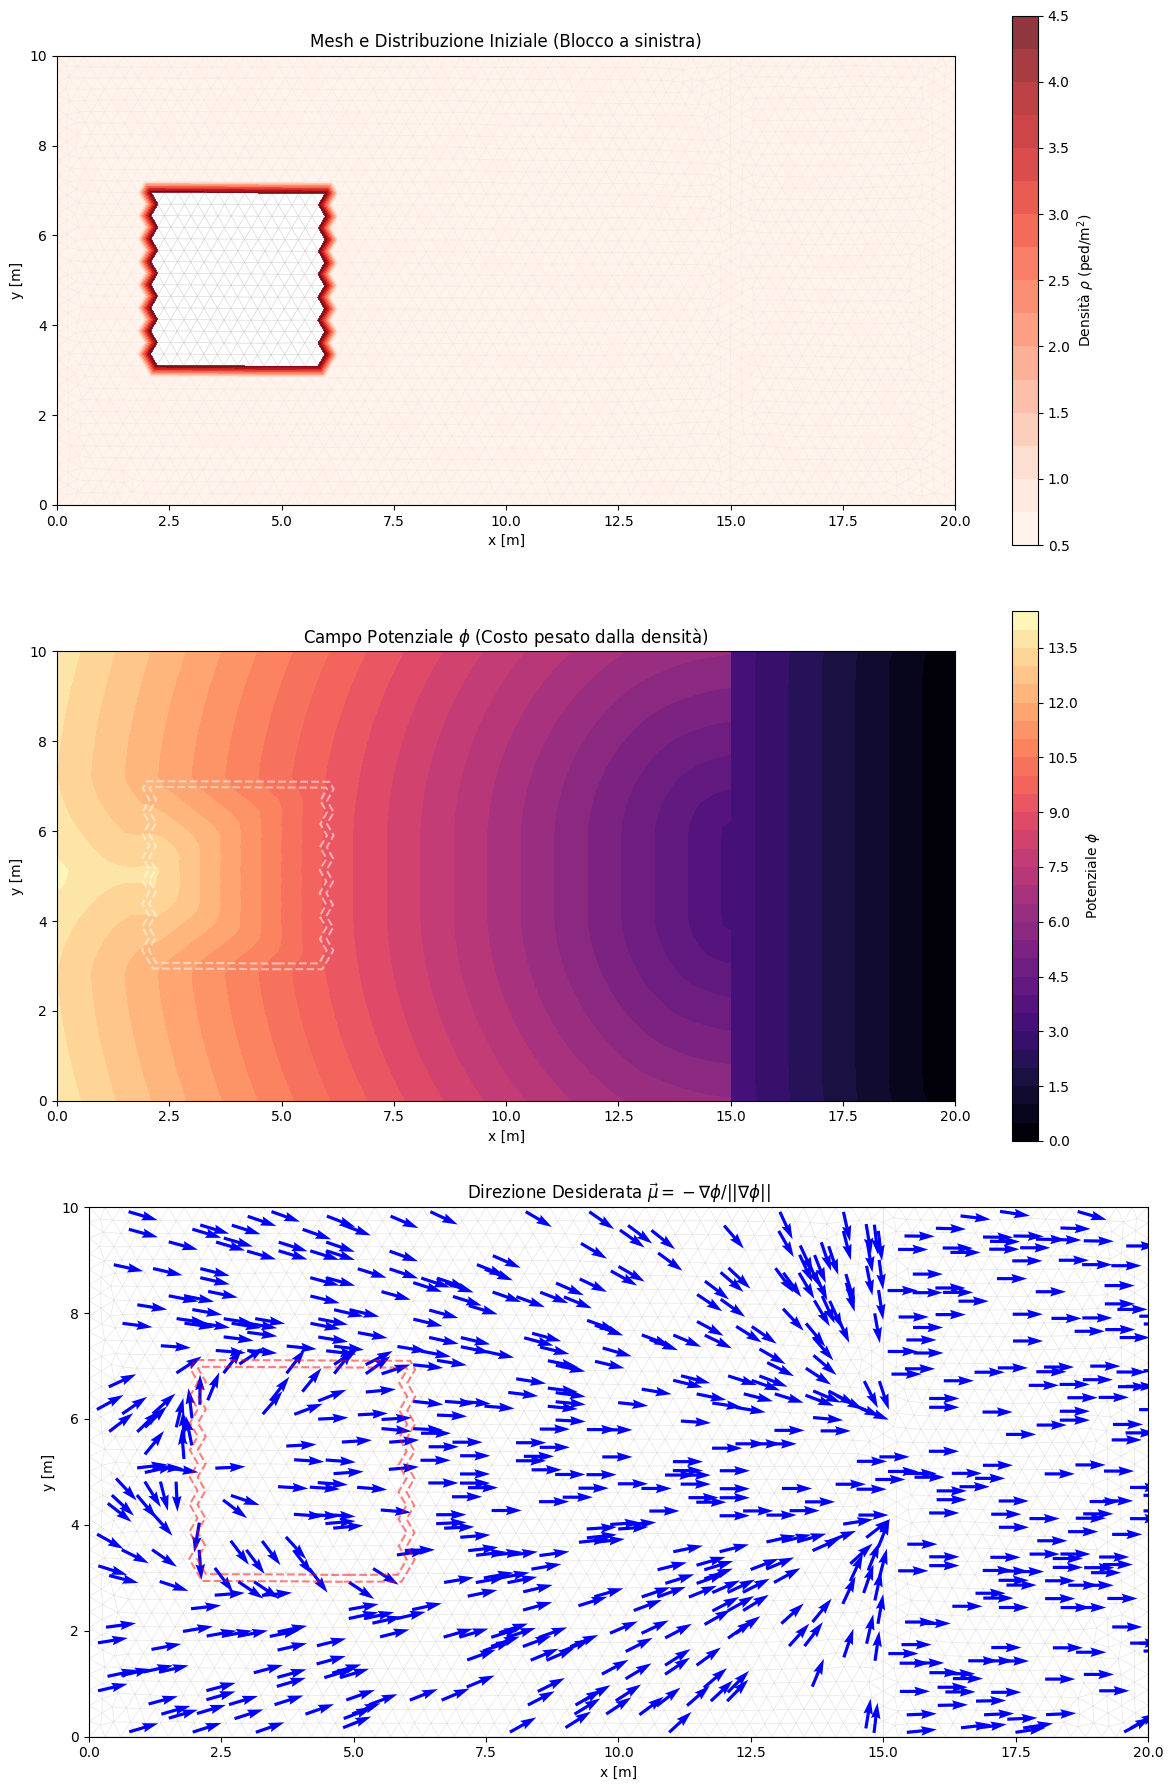

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri

# --- PARAMETRI FISICI ---
V_MAX = 1.5
RHO_MAX = 6.0
ALPHA = 0.9

def get_velocity(rho):
    """Modello esponenziale V(rho) = v_max * exp(-alpha * (rho/rho_max)^2)"""
    return V_MAX * np.exp(-ALPHA * (rho / RHO_MAX)**2)

def get_cost(rho):
    """Il costo c(rho) = 1 / V(rho)"""
    v = get_velocity(rho)
    return 1.0 / v

# --- SOLVER BORNEMANN & RASCH ---
def B_and_R_update_step(x0, x1, x2, T1, T2, rho_tri):
    f = get_cost(rho_tri)
    
    e1 = x1 - x0
    e2 = x2 - x0
    
    a11, a12, a22 = np.dot(e1, e1), np.dot(e1, e2), np.dot(e2, e2)
    detA = a11 * a22 - a12**2
    invA11, invA12, invA22 = a22/detA, -a12/detA, a11/detA
    
    c1 = invA11 + 2*invA12 + invA22
    c2 = -2 * (T1 * (invA11 + invA12) + T2 * (invA12 + invA22))
    c3 = T1**2 * invA11 + 2*T1*T2*invA12 + T2**2 * invA22 - f**2
    
    delta = c2**2 - 4*c1*c3
    t_new = np.inf
    
    if delta >= 0:
        t_quad = (-c2 + np.sqrt(delta)) / (2 * c1)
        g1 = invA11 * (t_quad - T1) + invA12 * (t_quad - T2)
        g2 = invA12 * (t_quad - T1) + invA22 * (t_quad - T2)
        if g1 >= 0 and g2 >= 0:
            t_new = t_quad
            
    t_e1 = T1 + np.linalg.norm(e1) * f
    t_e2 = T2 + np.linalg.norm(e2) * f
    return min(t_new, t_e1, t_e2)

# --- SIMULAZIONE E PLOT ---
def run_simulation_and_plot(nodes, triangles, outflow):
    N = len(nodes)
    T = np.full(N, np.inf)
    for idx in outflow: T[idx] = 0.0
    
    # 1. Definizione della densità a "BLOCCO" lontana dalla porta
    rho_nodes = np.zeros(N)
    for i in range(N):
        x, y = nodes[i,0], nodes[i,1]
        # Definiamo un blocco rettangolare: x tra 2 e 6, y tra 3 e 7
        if 2.0 <= x <= 6.0 and 3.0 <= y <= 7.0:
            rho_nodes[i] = 4.5  # Alta congestione nel blocco
        else:
            rho_nodes[i] = 0.5  # Spazio libero
            
    # 2. Iterazione Gauss-Seidel (aumentata a 50 per propagazione completa)
    for _ in range(50):
        for tri_idx in triangles:
            for i in range(3):
                i0, i1, i2 = tri_idx[i], tri_idx[(i+1)%3], tri_idx[(i+2)%3]
                if i0 in outflow: continue
                
                rho_tri = (rho_nodes[i0] + rho_nodes[i1] + rho_nodes[i2]) / 3.0
                t_cand = B_and_R_update_step(nodes[i0], nodes[i1], nodes[i2], T[i1], T[i2], rho_tri)
                if t_cand < T[i0]: T[i0] = t_cand

    # Sostituiamo gli eventuali infiniti residui (aree non raggiunte) col massimo per evitare errori nel plot
    T_finite = np.where(T == np.inf, np.nanmax(T[T != np.inf]), T)

    # 3. Calcolo del gradiente per ricavare la direzione \mu
    triang = tri.Triangulation(nodes[:, 0], nodes[:, 1], triangles)
    interp = tri.LinearTriInterpolator(triang, T_finite)
    
    # Valutiamo il gradiente nei baricentri dei triangoli per il quiver plot
    x_centers = np.mean(nodes[triangles, 0], axis=1)
    y_centers = np.mean(nodes[triangles, 1], axis=1)
    
    grad_x, grad_y = interp.gradient(x_centers, y_centers)
    
    # Normalizzazione per trovare \mu = - \nabla \phi / ||\nabla \phi||
    norm_grad = np.sqrt(grad_x**2 + grad_y**2)
    norm_grad[norm_grad == 0] = 1.0 # Evita divisioni per zero
    
    mu_x = -grad_x / norm_grad
    mu_y = -grad_y / norm_grad

    # --- PLOT ---
    fig, axs = plt.subplots(3, 1, figsize=(12, 18))
    
    # Subplot 1: Mesh e Densità Iniziale
    axs[0].triplot(triang, color='gray', alpha=0.3, lw=0.5)
    cnt0 = axs[0].tricontourf(triang, rho_nodes, levels=15, cmap='Reds', alpha=0.8)
    fig.colorbar(cnt0, ax=axs[0], label='Densità $\\rho$ (ped/m$^2$)')
    axs[0].set_title("Mesh e Distribuzione Iniziale (Blocco a sinistra)")
    
    # Subplot 2: Campo Potenziale Phi
    cnt1 = axs[1].tricontourf(triang, T_finite, levels=30, cmap='magma')
    fig.colorbar(cnt1, ax=axs[1], label='Potenziale $\\phi$')
    # Sovrapponiamo i contorni della densità per riferimento visivo
    axs[1].tricontour(triang, rho_nodes, levels=[2.0, 4.0], colors='white', alpha=0.5, linestyles='dashed')
    axs[1].set_title("Campo Potenziale $\\phi$ (Costo pesato dalla densità)")
    
    # Subplot 3: Direzione Desiderata (Vector Field)
    axs[2].triplot(triang, color='gray', alpha=0.2, lw=0.5)
    # Sottocampioniamo i vettori per evitare di creare un grafico illeggibile
    step = max(1, len(x_centers) // 600) 
    axs[2].quiver(x_centers[::step], y_centers[::step], mu_x[::step], mu_y[::step], 
                  color='blue', scale=35, width=0.003)
    axs[2].tricontour(triang, rho_nodes, levels=[2.0, 4.0], colors='red', alpha=0.5, linestyles='dashed')
    axs[2].set_title("Direzione Desiderata $\\vec{\\mu} = -\\nabla \\phi / ||\\nabla \\phi||$")
    
    for ax in axs:
        ax.set_aspect('equal')
        ax.set_xlabel("x [m]")
        ax.set_ylabel("y [m]")
        
    plt.tight_layout()
    plt.show()

# Eseguiamo la funzione supponendo che nodes, triangles, outflow siano passati correttamente dal tuo script Gmsh
run_simulation_and_plot(nodes, triangles, outflow)

Costruiamo ora le celle su cui si basa il nostro metodo a volumi finiti 

In [8]:
def get_dual_mesh_properties(nodes, triangles):
    num_nodes = len(nodes)
    dual_areas = np.zeros(num_nodes)
    edges_dict = {}

    for tri_idx in triangles:
        # Coordinate dei vertici del triangolo
        p0, p1, p2 = nodes[tri_idx[0]], nodes[tri_idx[1]], nodes[tri_idx[2]]
        
        # Area del triangolo (Formula del cross product)
        area_tri = 0.5 * abs(p0[0]*(p1[1] - p2[1]) + p1[0]*(p2[1] - p0[1]) + p2[0]*(p0[1] - p1[1]))
        
        # Ogni nodo riceve 1/3 dell'area del triangolo
        for idx in tri_idx:
            dual_areas[idx] += area_tri / 3.0
            
        # Costruiamo gli edges e le normali integrate
        for i, j in [(0,1), (1,2), (2,0)]:
            idx_i, idx_j = tri_idx[i], tri_idx[j]
            edge = tuple(sorted((idx_i, idx_j)))
            
            # Calcolo normale al lato (Pj - Pi) ruotata di 90 gradi
            # n_int = [ (y_j - y_i), -(x_j - x_i) ] / 2
            # Questa è la normale integrata della faccia duale tra i e j
            p_i, p_j = nodes[idx_i], nodes[idx_j]
            dy = p_j[1] - p_i[1]
            dx = p_j[0] - p_i[0]
            # Normale che punta da "left" a "right" (se idx_i < idx_j)
            n_int = np.array([dy, -dx]) / 2.0
            
            if edge not in edges_dict:
                edges_dict[edge] = n_int
            else:
                # Se l'edge è condiviso (triangolo adiacente), sommiamo i contributi
                # In 2D median dual, il contributo dei due triangoli si somma perfettamente
                edges_dict[edge] += n_int

    return dual_areas, edges_dict

# Calcoliamo le proprietà
dual_areas, edges_dict = get_dual_mesh_properties(nodes, triangles)

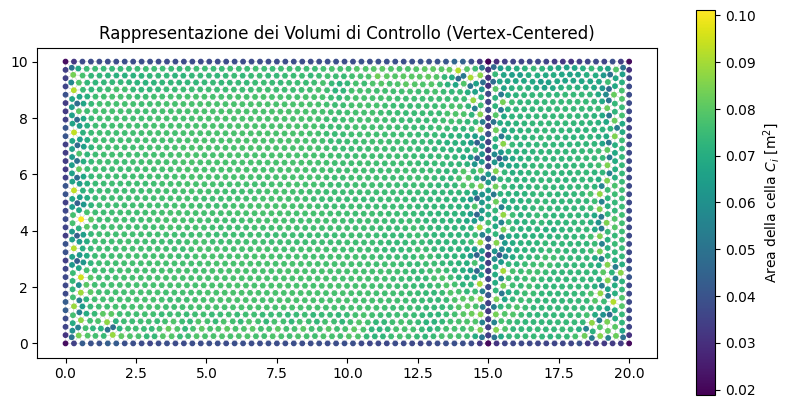

In [9]:
def plot_dual_mesh(nodes, triangles, dual_areas):
    plt.figure(figsize=(10, 5))
    triang = tri.Triangulation(nodes[:, 0], nodes[:, 1], triangles)
    plt.triplot(triang, color='lightgray', lw=0.5, label='Triangoli')
    
    # Rappresentazione simbolica delle celle (Coloriamo i nodi in base all'area duale)
    sc = plt.scatter(nodes[:, 0], nodes[:, 1], c=dual_areas, cmap='viridis', s=10)
    plt.colorbar(sc, label='Area della cella $C_i$ [m$^2$]')
    plt.title("Rappresentazione dei Volumi di Controllo (Vertex-Centered)")
    plt.gca().set_aspect('equal')
    plt.show()

plot_dual_mesh(nodes, triangles, dual_areas)

Calcolo del flusso tra due celle

In [10]:
import numpy as np

def pressure(rho, p_coeff=0.5, gamma=2.0):
    """Pressione sociale P(rho)"""
    return p_coeff * (rho**gamma)

def sound_speed_local(rho, p_coeff=0.5, gamma=2.0):
    """Velocità dell'informazione locale s = sqrt(P'(rho))"""
    if rho < 1e-10: return 0.0
    return np.sqrt(max(0, gamma * p_coeff * (rho**(gamma-1))))

def get_physical_flux(U, n, p_coeff=0.5, gamma=2.0):
    """
    Calcola il flusso fisico F(U) proiettato sulla normale n.
    F(U).n = [rho*vn, (rho*vx*vn + p*nx), (rho*vy*vn + p*ny)]
    """
    rho = U[0]
    if rho < 1e-10:
        return np.zeros(3)
    
    qx, qy = U[1], U[2]
    vx, vy = qx/rho, qy/rho
    vn = vx * n[0] + vy * n[1]
    
    p = pressure(rho, p_coeff, gamma)
    
    return np.array([
        rho * vn,
        qx * vn + p * n[0],
        qy * vn + p * n[1]
    ])

def compute_hll_flux(UL, UR, n_int, p_coeff=0.5, gamma=2.0):
    """
    Calcola il flusso numerico HLL tra due celle duali i (L) e j (R).
    
    UL, UR: Stati conservati [rho, qx, qy]
    n_int: Normale INTEGRATA (include la lunghezza dell'interfaccia)
    """
    # 1. Geometria dell'interfaccia duale
    area_faccia = np.linalg.norm(n_int)
    if area_faccia < 1e-14:
        return np.zeros(3)
    
    n = n_int / area_faccia # Normale unitaria
    
    # 2. Variabili primitive e velocità normali
    rhoL, rhoR = UL[0], UR[0]
    
    # Evitiamo divisioni per zero
    vL = UL[1:3] / rhoL if rhoL > 1e-10 else np.array([0.0, 0.0])
    vR = UR[1:3] / rhoR if rhoR > 1e-10 else np.array([0.0, 0.0])
    
    vLn = np.dot(vL, n)
    vRn = np.dot(vR, n)
    
    sL = sound_speed_local(rhoL, p_coeff, gamma)
    sR = sound_speed_local(rhoR, p_coeff, gamma)
    
    # 3. STATO IPOTETICO (Roe Averaging)
    # Media di Roe per la velocità normale
    sqrtL, sqrtR = np.sqrt(max(0, rhoL)), np.sqrt(max(0, rhoR))
    v_roe_n = (sqrtL * vLn + sqrtR * vRn) / (sqrtL + sqrtR + 1e-12)
    
    # Media di Roe per la velocità del suono
    delta_rho = rhoR - rhoL
    if abs(delta_rho) < 1e-6:
        s_bar = 0.5 * (sL + sR)
    else:
        # s_bar = sqrt( (P(rhoR) - P(rhoL)) / (rhoR - rhoL) )
        delta_p = pressure(rhoR, p_coeff, gamma) - pressure(rhoL, p_coeff, gamma)
        s_bar = np.sqrt(max(0, delta_p / delta_rho))
        
    # 4. Velocità delle onde (Wave Speeds)
    sigmaL = min(vLn - sL, v_roe_n - s_bar)
    sigmaR = max(v_roe_n + s_bar, vRn + s_bar)
    
    # 5. Calcolo del Flusso HLL (F_HLL)
    FL = get_physical_flux(UL, n, p_coeff, gamma)
    FR = get_physical_flux(UR, n, p_coeff, gamma)
    
    if sigmaL >= 0:
        # Caso 1: Flusso verso destra (supercritico)
        F_hll = FL
    elif sigmaR <= 0:
        # Caso 3: Flusso verso sinistra (supercritico)
        F_hll = FR
    else:
        # Caso 2: Stato "Star" (subcritico)
        # Formula: (sigmaR*FL - sigmaL*FR + sigmaL*sigmaR*(UR - UL)) / (sigmaR - sigmaL)
        F_hll = (sigmaR * FL - sigmaL * FR + sigmaL * sigmaR * (UR - UL)) / (sigmaR - sigmaL)
        
    # Restituiamo il flusso totale integrato sulla faccia
    return F_hll * area_faccia

Definiamo il termine di sorgente rilassativo

In [11]:
def equilibrium_speed(rho):
    """Modello esponenziale V(rho) = v_max * exp(-alpha * (rho/rho_max)^2)"""
    return V_MAX * np.exp(-ALPHA * (rho / RHO_MAX)**2)

def compute_source_term(U_i, mu_i, tau=0.5, v_max=1.34, rho_max=7.0):
    """
    Calcola il termine sorgente S(Ui).
    
    Parametri:
    ----------
    U_i   : array [rho, qx, qy] -> Stato attuale al nodo i
    mu_i  : array [mux, muy]   -> Direzione desiderata (normalizzata) dal gradiente di phi
    tau   : float              -> Tempo di risposta (default 0.5s)
    """
    rho = U_i[0]
    
    # Se non c'è nessuno, non c'è spinta
    if rho < 1e-10:
        return np.zeros(3)
    
    # 1. Calcoliamo la velocità attuale v = q / rho
    v_current = U_i[1:3] / rho
    
    # 2. Calcoliamo la velocità desiderata (modulo * direzione)
    v_equil_mag = equilibrium_speed(rho, v_max, rho_max)
    v_desired = v_equil_mag * mu_i
    
    # 3. Termine sorgente per il momento: rho * (v_des - v_curr) / tau
    # S = [0, rho*(v_des_x - v_curr_x)/tau, rho*(v_des_y - v_curr_y)/tau]
    source_q = rho * (v_desired - v_current) / tau
    
    return np.array([0.0, source_q[0], source_q[1]])

Boundary condition

In [12]:
import numpy as np
from collections import defaultdict

EPS = 1e-12
L_DOMAIN = 20.0
W_DOMAIN = 10.0
X_OUTFLOW = 20.0
TOL = 1e-8


def build_edge_to_triangle_map(triangles):
    """
    Restituisce una mappa edge -> lista di triangoli adiacenti.
    Un edge di boundary compare una sola volta.
    """
    edge_to_tri = defaultdict(list)

    for k, tri in enumerate(triangles):
        a, b, c = tri
        for e in [(a, b), (b, c), (c, a)]:
            edge = tuple(sorted(e))
            edge_to_tri[edge].append(k)

    return edge_to_tri


def extract_boundary_edges(triangles):
    edge_to_tri = build_edge_to_triangle_map(triangles)
    boundary_edges = [e for e, adj in edge_to_tri.items() if len(adj) == 1]
    return boundary_edges, edge_to_tri


def outward_normal_for_boundary_edge(nodes, edge, tri_idx, triangles):
    """
    Calcola la normale unitaria uscente rispetto al dominio
    usando il triangolo adiacente al bordo.
    """
    i, j = edge
    pi, pj = nodes[i], nodes[j]
    t = pj - pi

    # normale perpendicolare al segmento
    n = np.array([t[1], -t[0]], dtype=float)

    # triangolo interno adiacente
    c = nodes[triangles[tri_idx]].mean(axis=0)
    mid = 0.5 * (pi + pj)

    # se la normale punta verso l'interno, la invertiamo
    if np.dot(n, c - mid) > 0:
        n = -n

    norm_n = np.linalg.norm(n)
    if norm_n < EPS:
        return np.array([0.0, 0.0])

    return n / norm_n


def wall_ghost_state(Ui, n):
    """
    Free-slip wall:
    rho_g = rho_i
    v_g   = v_i - 2 (v_i · n) n
    """
    rho = Ui[0]
    if rho < EPS:
        return Ui.copy()

    v = Ui[1:3] / rho
    vn = np.dot(v, n)
    v_g = v - 2.0 * vn * n

    return np.array([rho, rho * v_g[0], rho * v_g[1]])


def outflow_ghost_state(Ui):
    """
    Outflow a gradiente nullo:
    U_g = U_i
    """
    return Ui.copy()


def classify_boundary_edge(nodes, edge):
    """
    Classificazione geometrica semplice:
    - x = X_OUTFLOW -> outflow
    - tutto il resto -> wall
    """
    i, j = edge
    mid = 0.5 * (nodes[i] + nodes[j])

    if abs(mid[0] - X_OUTFLOW) < 1e-6:
        return "outflow"
    return "wall"


def apply_boundary_flux(U, nodes, triangles, dual_areas):
    """
    Esempio di contributo di bordo al termine di flusso.
    U ha shape (N, 3), con U[i] = [rho, qx, qy].
    """
    boundary_edges, edge_to_tri = extract_boundary_edges(triangles)

    rhs = np.zeros_like(U)

    for edge in boundary_edges:
        tri_idx = edge_to_tri[edge][0]
        i, j = edge

        kind = classify_boundary_edge(nodes, edge)
        n = outward_normal_for_boundary_edge(nodes, edge, tri_idx, triangles)

        # lunghezza del bordo
        edge_len = np.linalg.norm(nodes[j] - nodes[i])
        n_int = n * edge_len  # normale integrata

        # scegliamo lo stato fantasma
        Ui = U[i]  # per un approccio vertex-centered semplice
        if kind == "wall":
            Ug = wall_ghost_state(Ui, n)
        else:
            Ug = outflow_ghost_state(Ui)

        # flusso numerico
        F = compute_hll_flux(Ui, Ug, n_int)

        # contributo al nodo i
        rhs[i] -= F / max(dual_areas[i], EPS)

    return rhs

Aggiornamento temporale

In [13]:
# === CELLA 1: BC + aggiornamento temporale (Eulero esplicito) ===

import numpy as np
import matplotlib.tri as tri
import matplotlib.animation as animation
from collections import defaultdict
from IPython.display import HTML

# -----------------------------
# Inizializzazione densità
# -----------------------------
def initial_density(nodes):
    """
    Condizione iniziale usata all'inizio:
    blocco ad alta densità a sinistra, densità bassa altrove.
    """
    rho0 = np.full(len(nodes), 0.5, dtype=float)
    mask = (nodes[:, 0] >= 2.0) & (nodes[:, 0] <= 6.0) & (nodes[:, 1] >= 3.0) & (nodes[:, 1] <= 7.0)
    rho0[mask] = 4.5
    return rho0


# -----------------------------
# Campo di direzione desiderata mu
# -----------------------------
def compute_desired_direction(nodes, triangles, outflow, rho_for_cost, n_relax=50):
    """
    Calcola il potenziale T con Bornemann-Rasch e ricava mu = -grad(T)/||grad(T)||.
    """
    N = len(nodes)
    T = np.full(N, np.inf, dtype=float)
    outflow_set = set(outflow)

    for idx in outflow:
        T[idx] = 0.0

    # propagazione del potenziale
    for _ in range(n_relax):
        changed = False
        for tri_idx in triangles:
            for k in range(3):
                i0, i1, i2 = tri_idx[k], tri_idx[(k + 1) % 3], tri_idx[(k + 2) % 3]
                if i0 in outflow_set:
                    continue

                rho_tri = (rho_for_cost[i0] + rho_for_cost[i1] + rho_for_cost[i2]) / 3.0
                t_cand = B_and_R_update_step(nodes[i0], nodes[i1], nodes[i2], T[i1], T[i2], rho_tri)

                if t_cand < T[i0]:
                    T[i0] = t_cand
                    changed = True

        if not changed:
            break

    finite_mask = np.isfinite(T)
    if not np.any(finite_mask):
        raise RuntimeError("Non riesco a costruire il campo di potenziale T: nessun valore finito trovato.")

    T_finite = T.copy()
    T_finite[~finite_mask] = np.nanmax(T[finite_mask])

    triang = tri.Triangulation(nodes[:, 0], nodes[:, 1], triangles)
    interp = tri.LinearTriInterpolator(triang, T_finite)

    gx, gy = interp.gradient(nodes[:, 0], nodes[:, 1])
    gx = np.asarray(gx.filled(0.0) if hasattr(gx, "filled") else gx, dtype=float)
    gy = np.asarray(gy.filled(0.0) if hasattr(gy, "filled") else gy, dtype=float)

    gnorm = np.sqrt(gx**2 + gy**2)
    gnorm[gnorm < 1e-14] = 1.0

    mu_nodes = np.column_stack((-gx / gnorm, -gy / gnorm))
    return T_finite, mu_nodes


# -----------------------------
# BC: classificazione bordo e normali
# -----------------------------
def classify_boundary_edge(nodes, edge, x_outflow=20.0, tol=1e-6):
    """
    Classifica un edge di bordo:
    - x = x_outflow -> outflow
    - tutto il resto -> wall
    """
    i, j = edge
    mid = 0.5 * (nodes[i] + nodes[j])
    if abs(mid[0] - x_outflow) < tol:
        return "outflow"
    return "wall"


def outward_normal_for_boundary_edge(nodes, edge, tri_idx, triangles):
    """
    Normale unitaria uscente dal dominio per un edge di bordo.
    """
    i, j = edge
    p_i, p_j = nodes[i], nodes[j]
    t = p_j - p_i

    # normale perpendicolare
    n = np.array([t[1], -t[0]], dtype=float)

    # controllo orientamento usando il baricentro del triangolo interno
    c = nodes[triangles[tri_idx]].mean(axis=0)
    mid = 0.5 * (p_i + p_j)

    # se punta verso l'interno, la invertiamo
    if np.dot(n, c - mid) > 0:
        n = -n

    nrm = np.linalg.norm(n)
    if nrm < 1e-14:
        return np.array([0.0, 0.0])

    return n / nrm


def wall_ghost_state(Ui, n):
    """
    Free-slip wall:
    rho_g = rho_i
    v_g = v_i - 2 (v_i · n) n
    """
    rho = Ui[0]
    if rho < 1e-12:
        return Ui.copy()

    v = Ui[1:3] / rho
    vn = np.dot(v, n)
    vg = v - 2.0 * vn * n
    return np.array([rho, rho * vg[0], rho * vg[1]], dtype=float)


def outflow_ghost_state(Ui):
    """
    Outflow a gradiente nullo.
    """
    return Ui.copy()


def build_edge_data(nodes, triangles):
    """
    Costruisce:
    - edge interni
    - edge di bordo con tipo (wall/outflow)
    """
    edge_to_tri = defaultdict(list)

    for t_idx, tri_idx in enumerate(triangles):
        for a, b in [(0, 1), (1, 2), (2, 0)]:
            edge = tuple(sorted((tri_idx[a], tri_idx[b])))
            edge_to_tri[edge].append(t_idx)

    interior_edges = []
    boundary_edges = []

    for edge, adj in edge_to_tri.items():
        i, j = edge
        p_i, p_j = nodes[i], nodes[j]

        # normale integrata "di faccia" per edge interno
        n_int = 0.5 * np.array([p_j[1] - p_i[1], -(p_j[0] - p_i[0])], dtype=float)

        if len(adj) == 2:
            interior_edges.append((i, j, n_int))
        elif len(adj) == 1:
            tri_idx = adj[0]
            kind = classify_boundary_edge(nodes, edge)
            n_out = outward_normal_for_boundary_edge(nodes, edge, tri_idx, triangles)
            edge_len = np.linalg.norm(p_j - p_i)
            boundary_edges.append((i, j, n_out * edge_len, kind))

    return interior_edges, boundary_edges


# -----------------------------
# Sorgente Payne-Whitham
# -----------------------------
def equilibrium_speed_local(rho, v_max=V_MAX, rho_max=RHO_MAX):
    return v_max * np.exp(-ALPHA * (rho / rho_max) ** 2)


def compute_source_term_pw(U_i, mu_i, tau=0.5, v_max=V_MAX, rho_max=RHO_MAX):
    """
    S(U) = [0, rho*(v_des - v)/tau]
    """
    rho = U_i[0]
    if rho < 1e-12:
        return np.zeros(3, dtype=float)

    v_current = U_i[1:3] / rho
    v_des_mag = equilibrium_speed_local(rho, v_max=v_max, rho_max=rho_max)
    v_desired = v_des_mag * mu_i

    source_q = rho * (v_desired - v_current) / tau
    return np.array([0.0, source_q[0], source_q[1]], dtype=float)


# -----------------------------
# CFL time step
# -----------------------------
def estimate_dt(U, dual_areas, cfl=0.15, p_coeff=0.5, gamma=2.0):
    rho = U[:, 0]
    vel = np.zeros((len(U), 2), dtype=float)

    mask = rho > 1e-12
    vel[mask] = U[mask, 1:3] / rho[mask, None]

    s = np.array([sound_speed_local(r, p_coeff=p_coeff, gamma=gamma) for r in rho], dtype=float)
    wave_speed = np.linalg.norm(vel, axis=1) + s
    max_speed = max(np.max(wave_speed), 1e-8)

    h_min = np.sqrt(np.min(dual_areas[dual_areas > 1e-14]))
    return cfl * h_min / max_speed


# -----------------------------
# Rhs dei flussi
# -----------------------------
def compute_flux_rhs(U, nodes, triangles, dual_areas, interior_edges, boundary_edges,
                     p_coeff=0.5, gamma=2.0):
    rhs = np.zeros_like(U)
    eps = 1e-14

    # edge interni
    for i, j, n_int in interior_edges:
        Fij = compute_hll_flux(U[i], U[j], n_int, p_coeff=p_coeff, gamma=gamma)
        rhs[i] -= Fij / max(dual_areas[i], eps)
        rhs[j] += Fij / max(dual_areas[j], eps)

    # bordi: wall / outflow
    for i, j, n_int, kind in boundary_edges:
        n_unit = n_int / max(np.linalg.norm(n_int), eps)

        # distribuiamo il contributo ai due estremi del segmento di bordo
        for k in (i, j):
            Uk = U[k]
            Ug = wall_ghost_state(Uk, n_unit) if kind == "wall" else outflow_ghost_state(Uk)

            # metà faccia per ciascun estremo
            Fk = compute_hll_flux(Uk, Ug, 0.5 * n_int, p_coeff=p_coeff, gamma=gamma)
            rhs[k] -= Fk / max(dual_areas[k], eps)

    return rhs


# -----------------------------
# Un passo di Eulero esplicito
# -----------------------------
def explicit_euler_step(U, dt, nodes, triangles, dual_areas, interior_edges, boundary_edges, mu_nodes,
                        tau=0.5, p_coeff=0.5, gamma=2.0):
    """
    U_i^{n+1} = U_i^* + dt S(U_i^*)
    con
    U_i^* = U_i^n - dt/|C_i| sum_j |e_ij| F(U_i^n, U_j^n, n_ij)
    """
    flux_rhs = compute_flux_rhs(U, nodes, triangles, dual_areas, interior_edges, boundary_edges,
                                p_coeff=p_coeff, gamma=gamma)

    U_star = U + dt * flux_rhs

    source = np.zeros_like(U_star)
    for i in range(len(U_star)):
        source[i] = compute_source_term_pw(U_star[i], mu_nodes[i], tau=tau)

    U_new = U_star + dt * source

    # protezione numerica
    U_new[:, 0] = np.maximum(U_new[:, 0], 1e-10)
    small = U_new[:, 0] < 1e-8
    U_new[small, 1:] = 0.0

    return U_new

In [ ]:
# === CELLA 2: simulazione + animazione densità ===

# Campo iniziale
rho0 = initial_density(nodes)

U = np.zeros((len(nodes), 3), dtype=float)
U[:, 0] = rho0
U[:, 1:] = 0.0

# Direzione desiderata (dalla funzione potenziale)
T_finite, mu_nodes = compute_desired_direction(nodes, triangles, outflow, rho0, n_relax=50)

# Geometria FV/dual
interior_edges, boundary_edges = build_edge_data(nodes, triangles)

# Parametri temporali
t_end = 15.0
cfl = 0.15
tau = 0.8
save_every = 3

# Simulazione
snapshots = [(0.0, U[:, 0].copy())]
times = [0.0]

t = 0.0
step = 0
max_steps = 5000

while t < t_end and step < max_steps:
    dt = estimate_dt(U, dual_areas, cfl=cfl, p_coeff=0.5, gamma=2.0)
    dt = min(dt, 0.05, t_end - t)

    U = explicit_euler_step(
        U, dt,
        nodes, triangles, dual_areas,
        interior_edges, boundary_edges, mu_nodes,
        tau=tau, p_coeff=0.5, gamma=2.0
    )

    t += dt
    step += 1

    if step % save_every == 0 or t >= t_end:
        snapshots.append((t, U[:, 0].copy()))
        times.append(t)

print(f"Simulazione completata: {step} passi, {len(snapshots)} frame salvati.")

# Animazione
triang = tri.Triangulation(nodes[:, 0], nodes[:, 1], triangles)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

rho_min = min(s[1].min() for s in snapshots)
rho_max = max(s[1].max() for s in snapshots)

t0, rho_init = snapshots[0]
tpc = ax.tripcolor(triang, rho_init, shading="gouraud", cmap="Reds", vmin=rho_min, vmax=rho_max)
cb = fig.colorbar(tpc, ax=ax, label="Densità $\\rho$ [ped/m$^2$]")
title = ax.set_title(f"t = {t0:.2f} s")

def update(frame):
    t_frame, rho_frame = snapshots[frame]
    tpc.set_array(rho_frame)
    title.set_text(f"t = {t_frame:.2f} s")
    return tpc, title

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(snapshots),
    interval=80,
    blit=False
)

plt.close(fig)
HTML(anim.to_jshtml())

C:\Users\Utente1\AppData\Local\Temp\ipykernel_13016\1457796382.py:32: RuntimeWarning: invalid value encountered in scalar add
  c3 = T1**2 * invA11 + 2*T1*T2*invA12 + T2**2 * invA22 - f**2
C:\Users\Utente1\AppData\Local\Temp\ipykernel_13016\1457796382.py:32: RuntimeWarning: invalid value encountered in scalar multiply
  c3 = T1**2 * invA11 + 2*T1*T2*invA12 + T2**2 * invA22 - f**2
